In [13]:
import pandas as pd
import matplotlib.pyplot as plt


def process_data(data):

	file_sizes = [102400, 204800, 307200, 409600, 512000, 614400, 716800, 819200, 921600, 1048576]

	data = data[data['file size(bytes)'].isin(file_sizes)]
	data['speed(kb/s)'] = data[' speed(bytes/s)']*8/1024
	data['file size(KB)'] = data['file size(bytes)']/1024
	data[' time taken(s)'] = pd.to_numeric(data[' time taken(s)'], errors='coerce')
	return data

In [14]:
data_jio = pd.read_csv('jio_file_transfer.log')
data_jio = process_data(data_jio.copy())

In [15]:
data_airtel = pd.read_csv('airtel_file_transfer.log')
data_airtel = process_data(data_airtel.copy())

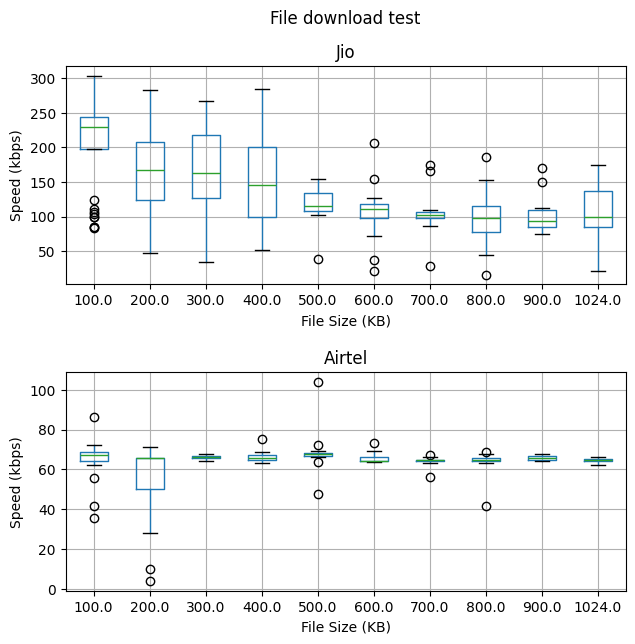

In [31]:
fig, axs = plt.subplots(2, 1)
fig.set_size_inches(7, 7)
data_jio.boxplot(column="speed(kb/s)", by="file size(KB)", grid=True, ax=axs[0])
data_airtel.boxplot(column="speed(kb/s)", by="file size(KB)", grid=True, ax=axs[1])
axs[0].set_title("Jio")
axs[1].set_title("Airtel")
axs[0].set_xlabel("File Size (KB)")
axs[1].set_xlabel("File Size (KB)")
axs[0].set_ylabel("Speed (kbps)")
axs[1].set_ylabel("Speed (kbps)")
plt.suptitle("File download test")
plt.subplots_adjust(hspace=0.4)
plt.savefig('Plots/file_transfer_speed.svg')
plt.show()


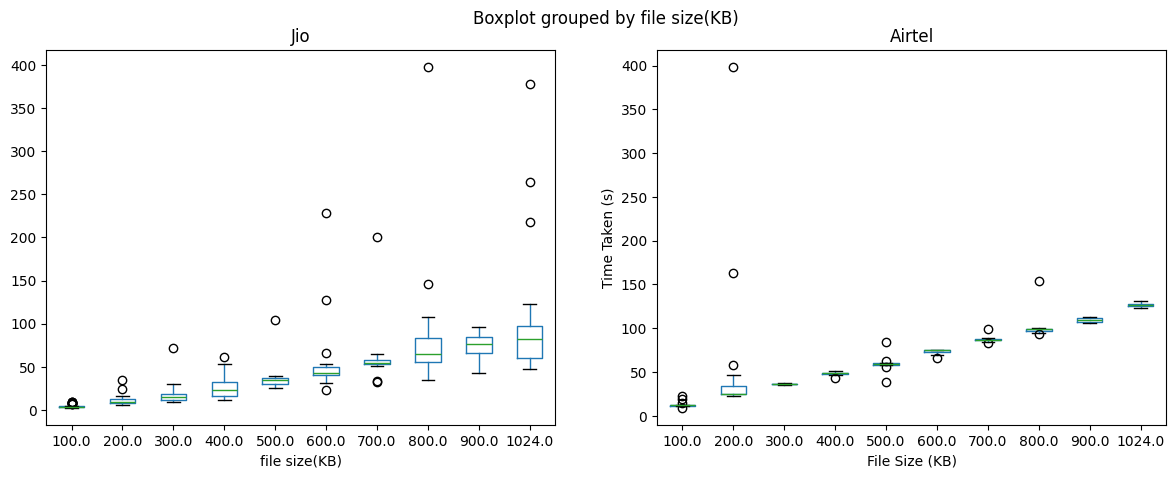

In [11]:
fig, axs = plt.subplots(1, 2)
fig.set_size_inches(14, 5)
data_jio.boxplot(column=" time taken(s)", by="file size(KB)", grid=False, ax=axs[0])
data_airtel.boxplot(column=" time taken(s)", by="file size(KB)", grid=False, ax=axs[1])
axs[0].set_title("Jio")
axs[1].set_title("Airtel")
plt.xlabel("File Size (KB)")
plt.ylabel("Time Taken (s)")
plt.show()